In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [4]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
from typing import List, Tuple


class GridProblem:
    MOVES = {"UP": (-1, 0), "DOWN": (1, 0), "LEFT": (0, -1), "RIGHT": (0, 1)}

    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self):
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []

        for action, (dr, dc) in self.MOVES.items():
            next_state = (state[0] + dr, state[1] + dc)

            if self.in_bounds(next_state) and self.is_free(next_state):
                legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = self.MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state) -> float:
        return 1


In [13]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [14]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [15]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [ ]:
from typing import Iterable


class SearchAlgorithm(ABC):
    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state

        for action in problem.actions(state):
            next_state = problem.result(state, action)

            new_cost = node.path_cost + problem.action_cost(state, action, next_state)

            yield Node(
                state=next_state,
                parent=node,
                action=action,
                path_cost=new_cost,
                depth=node.depth + 1,
            )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
from collections import deque


class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0,
            depth=0,
        )

        nodes_expanded = 0
        max_frontier_size = 1

    
        if problem.is_goal(node.state):
            return SearchResult(
                solution=node,
                algorithm=algorithm,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                status="success",
            )

        frontier = deque([node])
        reached = {node.state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        solution=child,
                        algorithm=algorithm,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        status="success",
                    )

                if state not in reached:
                    reached.add(state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            solution=None,
            algorithm=algorithm,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            status="failure",
        )

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0,
            depth=0,
        )

        nodes_expanded = 0
        max_frontier_size = 1

        
        if problem.is_goal(node.state):
            return SearchResult(
                solution=node,
                algorithm=algorithm,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                status="success",
            )

        frontier = [node]
        reached = {node.state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                state = child.state

                if problem.is_goal(state):
                    return SearchResult(
                        solution=child,
                        algorithm=algorithm,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        status="success",
                    )

                if state not in reached:
                    reached.add(state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            solution=None,
            algorithm=algorithm,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            status="failure",
        )

In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0,
            depth=0,
        )

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: dict,
        current_stack_size: int,
    ):

        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            current_stack_size += 1
            metrics["max_stack_size"] = max(
                metrics["max_stack_size"], current_stack_size
            )

        
            result, status = self._recursive_dls(
                problem,
                child,
                limit,
                metrics,
                current_stack_size,
            )

            if status == "success":
                return result, "success"

            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return None, "cutoff"
        else:
            return None, "failure"

In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded = 0
        max_frontier_size = 1

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)

            iteration_log.append(
                {
                    "limit": limit,
                    "status": result.status,
                    "nodes_expanded": result.nodes_expanded,
                    "max_frontier_size": result.max_frontier_size,
                }
            )

            total_nodes_expanded += result.nodes_expanded
            max_frontier_size = max(max_frontier_size, result.max_frontier_size)

            if result.status == "success":
                return SearchResult(
                    solution=result.solution,
                    algorithm=algorithm,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iteration_log,
                    status="success",
                )

            if result.status == "failure":
                return SearchResult(
                    solution=None,
                    algorithm=algorithm,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iteration_log,
                    status="failure",
                )

        return SearchResult(
            solution=None,
            algorithm=algorithm,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_frontier_size,
            iterations=iteration_log,
            status="cutoff",
        )

In [31]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,18,4,0
2,DLS,cutoff,10.0,NaN,NaN,16,13,0
3,IDS,success,NaN,18.0,18.0,356,22,0


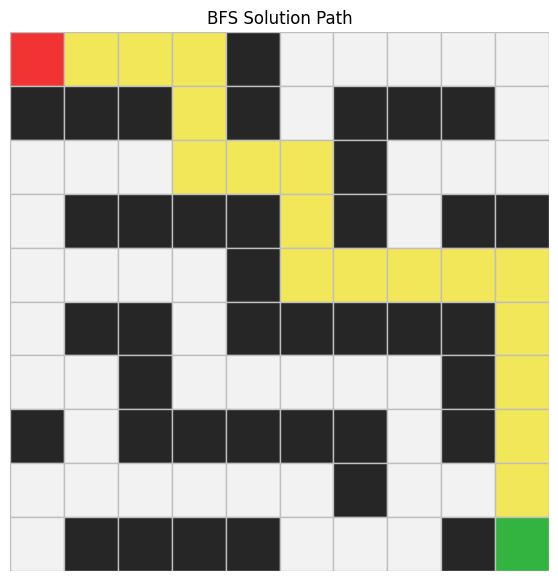

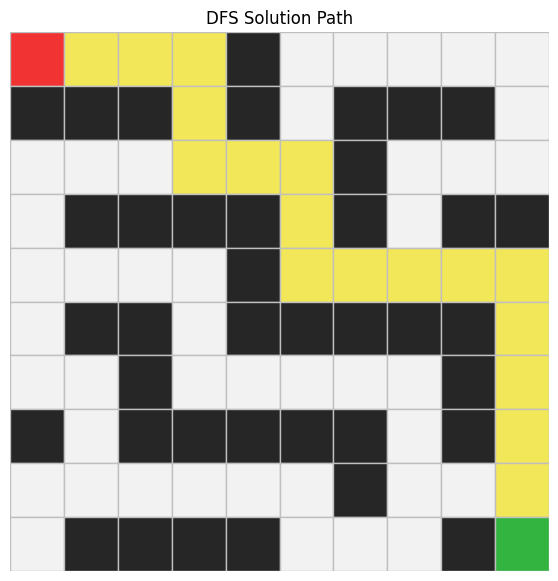

In [32]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

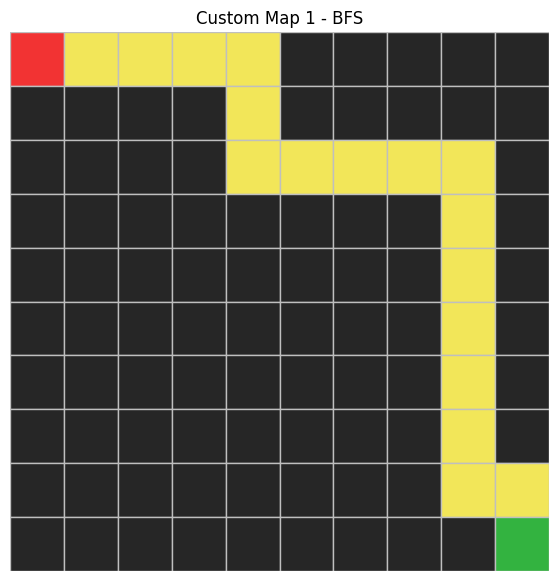

In [ ]:
custom_grid_1 = [
    [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

show_results(custom_results_1)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom Map 1 - BFS",
)

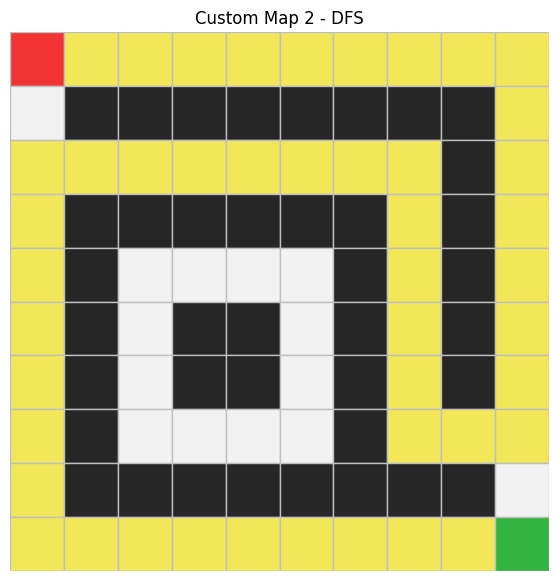

In [ ]:
custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

show_results(custom_results_2)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="Custom Map 2 - DFS",
)


In [ ]:
""" 15.1 Problem Formulation 
1. A state represents any place the drone's find itselfon the grid expressed as (row, column)

2. An action is the allowed movements the drone can make(up, down, left or right)

3. The result function returns the new state a drone finds itself after applying an action to  its current state.

4. Separating the problem definition from the search algorithm allows room for different problems to use the same algorithm without any changes.



15.2 BFS
1. BFS explores nodes in the order they are discovered hence the first (oldest)
nodes are expanded in that order.

2. Because BFS expands nodes level by level, hence it reaches the goal through the smallest number of moves when all moves have the same cost.

3. The reached set prevents the drone from revisiting previously discovered states, avoiding cycles.



15.3 DFS
1. DFS uses stack because it follows the Last In First Out principle, making DFS to newly discovered node first and go deeper into the search space.

2. No because it returns the first solution it encounters, which cannot be guaranteeed as the shortest path to the goal.

3. DFS uses less memory when the search tree is wide because it stores only current path and its few unexplored nodes down the path chosen by the drone to deeply explore unlike BFS that explores nodes widely, a level at a time, keeping all nodes encountered in its memory. 

4. DFS performs poorly when there are deep branches or many dead ends, since it may spend time exploring unproductive paths.



15.4 DLS
1. if the depth limit is too small, the search might not reach the goal and stops exploring deeper levels.

2. Cutoff means the search stopped because the depth limit was reached before determining whether a solution exists.

3. DLS is DFS with maximum depth limit that prevents the search from going deeper than it would have gone in DFS.

4. Path-cycle checking prevents the algorithm from revisiting states already on the current path, thereby avoiding infinite loop.




15.5 IDS
1. It repeats DFS with increasing limit until goal is found.

2. Because IDS continually increases the depth limit, it will eventually reach the depth of the solution.

3. IDS bahaves like DFS by storing nodes along the current path, thereby using less memory.

4. Shallow nodes are expanded multiple times, increasing the total number of node expansions.




15.6 REAL-WORLD DRONE CONTEXT
1. Factors like obstacles, terrain, weather, etc may make some routes safer or more practical.

2. I would choose BFS because it is complete and optimal, it guarantees the shortest path when all moves are equal.

3. DLS will be my choice because it limit the search to a specified maximum depth.

4. The model assumes fixed obstacles and same movement cost. Real drones must deal with varying weather, terrain, obstacles, etc.
"""